In [3]:
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install seaborn
%pip install joblib

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
train = pd.read_csv(
    "../data/raw/goemotions/train.tsv",
    sep="\t",
    header=None,
    names=["text", "label", "id"]
)

dev = pd.read_csv(
    "../data/raw/goemotions/dev.tsv",
    sep="\t",
    header=None,
    names=["text", "label", "id"]
)

test = pd.read_csv(
    "../data/raw/goemotions/test.tsv",
    sep="\t",
    header=None,
    names=["text", "label", "id"]
)

print(train.shape)
print(dev.shape)
print(test.shape)

(43410, 3)
(5426, 3)
(5427, 3)


In [5]:
train["primary_label"] = (
    train["label"]
    .apply(lambda x: int(str(x).split(",")[0]))
)

dev["primary_label"] = (
    dev["label"]
    .apply(lambda x: int(str(x).split(",")[0]))
)

test["primary_label"] = (
    test["label"]
    .apply(lambda x: int(str(x).split(",")[0]))
)

In [6]:
X_train_text = train["text"]
X_dev_text = dev["text"]
X_test_text = test["text"]

y_train = train["primary_label"]
y_dev = dev["primary_label"]
y_test = test["primary_label"]

In [7]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train_text)

X_dev = vectorizer.transform(X_dev_text)

X_test = vectorizer.transform(X_test_text)

print(X_train.shape)

(43410, 10000)


In [8]:
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logreg.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [9]:
y_pred_logreg = logreg.predict(X_test)

In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred_logreg
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_test,
        y_pred_logreg,
        average="macro"
    )
)

print("Accuracy:", accuracy)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1:", f1)

Accuracy: 0.39248203427307904
Macro Precision: 0.33254808489600324
Macro Recall: 0.463883846740529
Macro F1: 0.3665511820653515


In [12]:
logreg_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "Macro_F1": [f1]
})

logreg_results.to_csv(
    "../results/metrics/logreg_results.csv",
    index=False
)

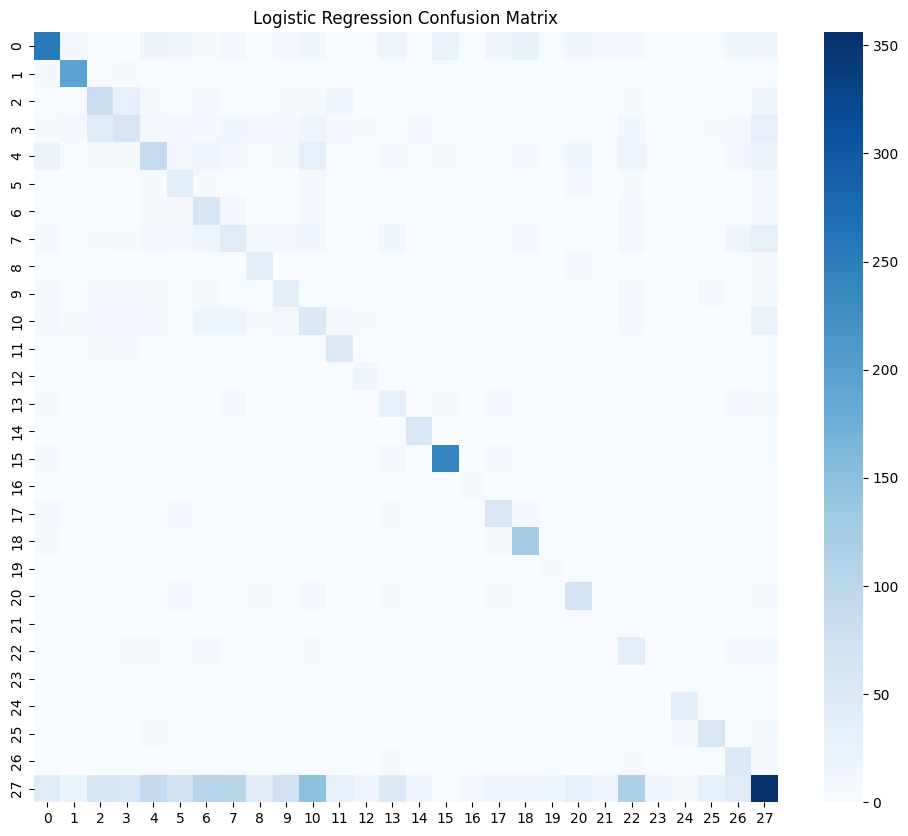

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred_logreg
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.savefig(
    "../results/confusion_matrices/logreg_cm.png",
    dpi=300
)

plt.show()

In [15]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(
    X_train,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [16]:
y_pred_svm = svm_model.predict(
    X_test
)

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_test,
        y_pred_svm,
        average="macro"
    )
)

print("Accuracy:", accuracy)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1:", f1)

Accuracy: 0.37276580062649717
Macro Precision: 0.29260169397926894
Macro Recall: 0.3987018241011992
Macro F1: 0.3244306804662504


In [18]:
svm_results = pd.DataFrame({
    "Model": ["Linear SVM"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "Macro_F1": [f1]
})

svm_results.to_csv(
    "../results/metrics/svm_results.csv",
    index=False
)

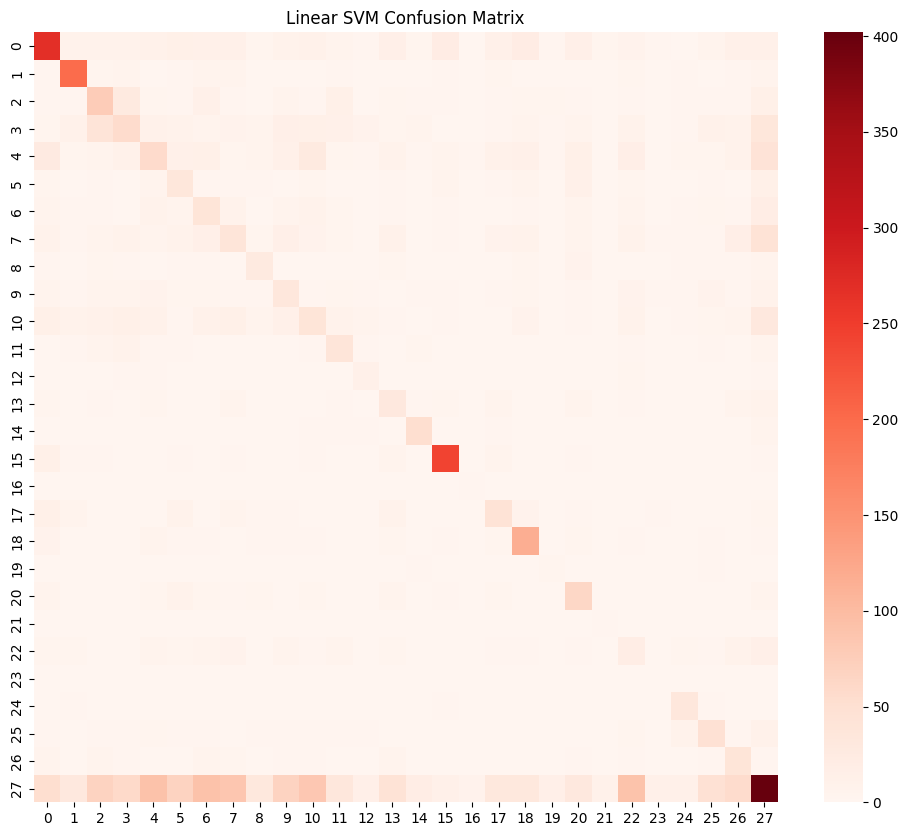

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Reds"
)

plt.title(
    "Linear SVM Confusion Matrix"
)

plt.savefig(
    "../results/confusion_matrices/svm_cm.png",
    dpi=300
)

plt.show()

In [21]:
comparison = pd.concat([
    logreg_results,
    svm_results
])

comparison

,Model,Accuracy,Precision,Recall,Macro_F1
0,Logistic Regression,0.392482,0.332548,0.463884,0.366551
0,Linear SVM,0.372766,0.292602,0.398702,0.324431


In [22]:
comparison.to_csv(
    "../results/metrics/classical_comparison.csv",
    index=False
)